# 02 — Baseline Models on FD001

Goal: train simple baseline models using sensor features only.

We split by **engine id**, not by random rows, to avoid leakage between train and validation.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.config import DEFAULT_RUL_CAP, RANDOM_STATE
from src.data.loading import load_train, sensor_columns
from src.features.build_features import add_rul_target, train_val_split_by_unit, prepare_xy
from src.models.train_baselines import fit_models, predict_models, evaluate_model_predictions
from src.visualization.plots import plot_actual_vs_predicted


In [3]:
df = load_train(DATA_DIR, "FD001")
df = add_rul_target(df, cap=DEFAULT_RUL_CAP)
train_df, val_df = train_val_split_by_unit(df, test_size=0.2, random_state=RANDOM_STATE)

features = sensor_columns(df)
X_train, y_train, X_val, y_val = prepare_xy(train_df, val_df, features)

print("Train engines:", train_df["unit"].nunique())
print("Validation engines:", val_df["unit"].nunique())
print("Features:", features)


Train engines: 80
Validation engines: 20
Features: ['s_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21']


## Train baselines

Models:
- Linear Regression — sanity-check baseline
- Decision Tree — simple nonlinear model
- Random Forest — bagged ensemble
- Gradient Boosting — sequential ensemble


In [4]:
fitted_models = fit_models(X_train, y_train, random_state=RANDOM_STATE)
predictions = predict_models(fitted_models, X_val)
metrics_df = evaluate_model_predictions(y_val, predictions)
metrics_df


,Model,MAE,RMSE,R2
0,Gradient Boosting,15.151342,20.187635,0.813987
1,Random Forest,15.233042,20.321485,0.811512
2,Decision Tree,17.418023,23.032319,0.757870
3,Linear Regression,18.824860,23.492424,0.748100


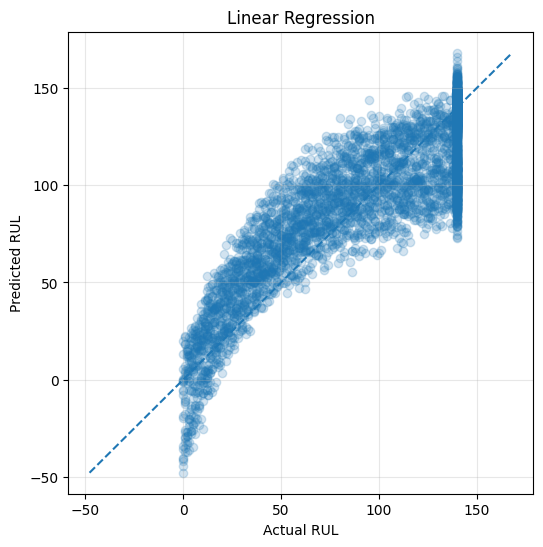

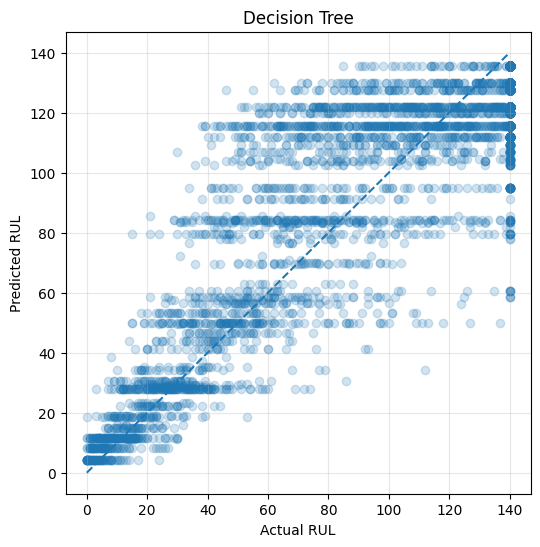

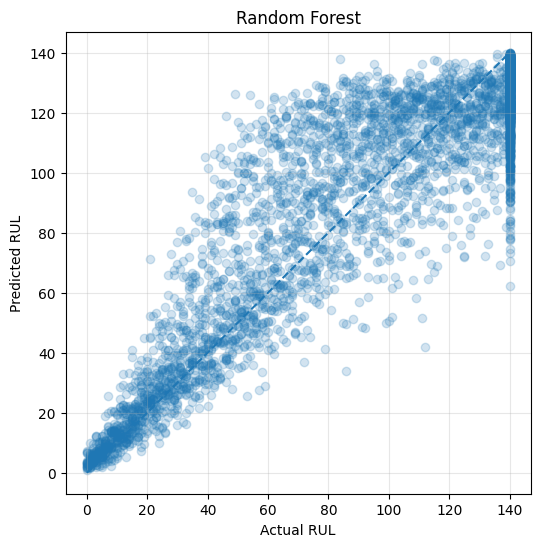

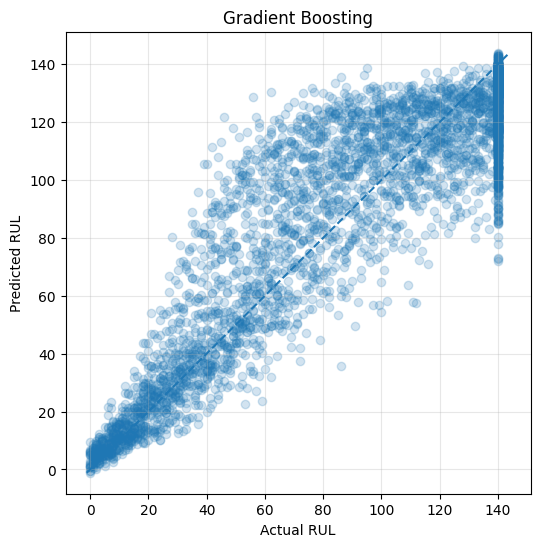

In [5]:
for model_name, y_pred in predictions.items():
    plot_actual_vs_predicted(y_val, y_pred, title=model_name)
    plt.show()


## Baseline interpretation template

Fill this after running the notebook:

- Best MAE model:
- Best RMSE model:
- Best R² model:
- Which model underpredicts/overpredicts near low RUL?
- Does the model look safe enough for maintenance decisions?


In [6]:
metrics_df.to_csv(PROCESSED_DIR / "fd001_baseline_metrics.csv", index=False)
print("Saved baseline metrics")


Saved baseline metrics
